# ROMP: Rainy Season Onset Metrics Package

ROMP is a Python package for detecting and benchmarking rainy season onset in observational and forecast datasets. It provides tools for onset detection, ensemble forecast statistics, binned and spatial metrics, and visualization workflows commonly used in climate research.

## Key Capabilities
* Rainy season onset detection with user-specified criteria
* Deterministic and probabilistic benchmarking metrics
* Skill Scores (overall and binned)
* Spatial metrics (MAE, False Alarm Rate, Miss Rate)
* Reliability diagrams and spatial maps
* Customizable region definitions (rectangular boundary, shapefile, polygon outline)
* Config-driven, reproducible workflows

## Outputs
Results are written to (default or user-specified dirs):
* **`output/`** — NetCDF and serialized metric files
* **`figure/`** — generated plots and maps

---
*Note: This notebook is configured to run the workflow interactively. Ensure your environment has Python ≥ 3.10 and dependencies like `xarray`, `netCDF4`, `cartopy`, and `geopandas` installed.*

In [1]:
import momp.lib.loader as loader 
from pathlib import Path
from IPython.display import Image, display
get_cfg = loader.get_cfg
cfg = get_cfg()
cfg.probabilistic=True,
base_dir = cfg.base_dir


package base dir /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/ai_weather/apps/benchmarking/ROMP/momp
Using config file: /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/ai_weather/apps/benchmarking/ROMP/momp/params/config.in
work_dir =  None
pkg_dir =  /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/ai_weather/apps/benchmarking/ROMP/momp
ref_model_dir =  /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/external/ENACTS
out_dir =  /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/output
out_fig =  /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure
obs_dir =  /Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/a

In [2]:
import momp.app.onset_time_series as ots
import importlib
ons = ots.obs_onset_analysis
print("region = ", cfg.region)


region =  Ethiopia


In [10]:
# # ==============================================================================
# # 1. CONFIG SETUP  (Points to actual Observation data location)
# # ==============================================================================
# config = importlib.reload(config)

# # Use the dynamically resolved PROJ_ROOT from config instead of hardcoding
# PROJ_ROOT = Path(config.PROJ_ROOT)

# # Point to actual Observation data directory
# OB_DIR = PROJ_ROOT / "data"  / "external" / "CHRIPS_IMERG"

# if not OB_DIR.is_dir():
#     raise FileNotFoundError(
#         f"ENACTS directory does not exist: {OB_DIR}\n"
#         f"Available dirs under {PROJ_ROOT / 'data'  }:\n"
#         + "\n".join(str(p.name) for p in (PROJ_ROOT / "data" ).iterdir())
#     )

# cfg = get_cfg()
# cfg.obs = "CHRIPS_IMERG"                    # Changed from CHIRPS
# cfg.obs_dir = str(ENACTS_DIR)         # Fixed path
# cfg.obs_file_pattern = ("{}.nc",) # Must match actual filenames
# cfg.obs_var = "RAINFALL"                # Match variable name in NetCDF
# cfg.ref_model_dir = str(ENACTS_DIR)   # Same dir for climatology
# cfg.ref_model_file_pattern = "{}.nc"

# base_kwargs = cfg.copy() if isinstance(cfg, dict) else vars(cfg).copy()
# for key in ("year", "lat_select", "lon_select"):
#     base_kwargs.pop(key, None)

# sig = inspect.signature(ots.obs_onset_analysis)
# if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values()):
#     base_kwargs = {k: v for k, v in base_kwargs.items() if k in sig.parameters}

In [3]:
%matplotlib inline
import html
import importlib
import inspect
import io
import sys
import time
import traceback
import warnings
from contextlib import contextmanager, redirect_stderr, redirect_stdout
from pathlib import Path
from unittest.mock import patch

import ipywidgets as widgets
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import Image, clear_output, display

import config
import momp.app.onset_time_series as ots

warnings.filterwarnings("ignore")

try:
    import geopandas as gpd
except ImportError:
    gpd = None


# ==============================================================================
# 0. FILTER FOR CUSTOM PRINTED WARNINGS
# ==============================================================================
class _FilteredStream:
    def __init__(self, stream, pattern):
        self.stream, self.pattern, self._skip_nl = stream, pattern, False

    def write(self, text):
        if self.pattern in text:
            self._skip_nl = True
            return len(text)
        if self._skip_nl and text == "\n":  # print() writes its newline separately
            self._skip_nl = False
            return 1
        self._skip_nl = False
        return self.stream.write(text)

    def __getattr__(self, name):  # flush, isatty, encoding, ...
        return getattr(self.stream, name)


@contextmanager
def suppress_print_pattern(pattern):
    old_out, old_err = sys.stdout, sys.stderr
    sys.stdout, sys.stderr = _FilteredStream(old_out, pattern), _FilteredStream(old_err, pattern)
    try:
        yield
    finally:
        sys.stdout, sys.stderr = old_out, old_err


# ==============================================================================
# 1. CONFIG SETUP  (needs `get_cfg` from the setup cell)
# ==============================================================================
config = importlib.reload(config)

CHIRPS_DIR = Path(getattr(
    config, "CHIRPS_DIR",
    Path(config.PROJ_ROOT) / "data" / "external" / "CHIRPS_IMERG",
))
if not CHIRPS_DIR.is_dir():
    raise FileNotFoundError(f"CHIRPS directory does not exist: {CHIRPS_DIR}")

cfg = get_cfg()
cfg.obs = "CHIRPS"
cfg.obs_dir = str(CHIRPS_DIR)
cfg.obs_file_pattern = ("{}.nc",)
cfg.obs_var = "RAINFALL"
cfg.ref_model_dir = str(CHIRPS_DIR)
cfg.ref_model_file_pattern = "{}.nc"

base_kwargs = cfg.copy() if isinstance(cfg, dict) else vars(cfg).copy()
for key in ("year", "lat_select", "lon_select"):
    base_kwargs.pop(key, None)

sig = inspect.signature(ots.obs_onset_analysis)
if not any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values()):
    base_kwargs = {k: v for k, v in base_kwargs.items() if k in sig.parameters}


# ==============================================================================
# 2. HELPERS
# ==============================================================================
def available_years(default=range(2015, 2024)):
    """Years that have an observation file on disk."""
    pattern = cfg.obs_file_pattern
    pattern = pattern[0] if isinstance(pattern, (tuple, list)) else pattern
    years = [y for y in range(1980, 2031) if (CHIRPS_DIR / pattern.format(y)).is_file()]
    return years or list(default)


def snap_to_grid(lat, lon, data_dir):
    """Nearest exact (lat, lon) grid coordinates, regardless of key casing."""
    sample = next(data_dir.glob("*.nc"), None)
    if not sample:
        return lat, lon
    with xr.open_dataset(sample) as ds:
        lat_key = next((k for k in ds.variables if str(k).lower() in ("lat", "latitude", "y")), None)
        lon_key = next((k for k in ds.variables if str(k).lower() in ("lon", "longitude", "x")), None)
        if not lat_key or not lon_key:
            return lat, lon
        nlat = ds[lat_key].sel({lat_key: lat}, method="nearest").values.item()
        nlon = ds[lon_key].sel({lon_key: lon}, method="nearest").values.item()
    return float(nlat), float(nlon)


NAME_COLS = ("woreda", "w_name", "wname", "woreda_name", "wor_name", "adm3_en",
             "adm3_name", "admin3name", "name")
ZONE_COLS = ("zone", "z_name", "zone_name", "adm2_en", "admin2name")


def find_shapefile():
    """config.WOREDA_SHP if set, else the best-looking .shp under the data folder."""
    hint = getattr(config, "WOREDA_SHP", None)
    if hint and Path(hint).is_file():
        return Path(hint)
    root = Path(getattr(config, "DATA_DIR", Path(config.PROJ_ROOT) / "data"))
    found = list(root.rglob("*.shp")) if root.is_dir() else []
    preferred = [p for p in found if any(k in p.name.lower() for k in ("woreda", "wereda", "adm3"))]
    return (preferred or found or [None])[0]


def load_woredas(path):
    """Return {label: (lat, lon)} using a point guaranteed to lie inside each polygon."""
    if gpd is None:
        raise ImportError("geopandas is not installed: pip install geopandas")
    gdf = gpd.read_file(path)
    if gdf.crs is not None and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)
    lower = {c.lower(): c for c in gdf.columns}
    name_col = next((lower[c] for c in NAME_COLS if c in lower), None)
    if name_col is None:  # fall back to the first text column
        name_col = next(c for c in gdf.columns if c != gdf.geometry.name and gdf[c].dtype == object)
    zone_col = next((lower[c] for c in ZONE_COLS if c in lower), None)
    pts = gdf.geometry.representative_point()

    out = {}
    for i, name in enumerate(gdf[name_col].astype(str)):
        label = f"{name} ({gdf[zone_col].iloc[i]})" if zone_col else name
        if label in out:
            label = f"{label} #{i}"
        out[label] = (float(pts.iloc[i].y), float(pts.iloc[i].x))
    return dict(sorted(out.items()))


def _fig_png(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    return buf.getvalue()


def analyze_onset(year, lat, lon, label=None, return_pngs=False):
    """Snap to grid, run the onset analysis, and show (or return as PNG bytes) every figure."""
    grid_lat, grid_lon = snap_to_grid(lat, lon, CHIRPS_DIR)
    if label:
        print(f"---> Woreda: {label}")
    print(f"---> Requested: Year={year}, Lat={lat:.4f}, Lon={lon:.4f}")
    print(f"---> Snapped to nearest grid point: Lat={grid_lat:.4f}, Lon={grid_lon:.4f}")

    pngs = []
    plt.close("all")
    try:
        # keep figures alive so we can render them ourselves
        with suppress_print_pattern("specified region is not in cartopy"), \
             patch.object(plt, "show", lambda *a, **k: None), \
             patch.object(plt, "close", lambda *a, **k: None):
            ots.obs_onset_analysis(year=year, lat_select=grid_lat, lon_select=grid_lon, **base_kwargs)
        figs = [f for f in (plt.figure(n) for n in plt.get_fignums()) if f.get_axes()]
        print(f"---> figures captured: {len(figs)}")
        pngs = [_fig_png(f) for f in figs]
    finally:
        plt.close("all")

    if return_pngs:
        return pngs
    for png in pngs:
        display(Image(data=png))


# ==============================================================================
# 3. WIDGETS
# ==============================================================================
YEARS = available_years()
wide = widgets.Layout(width="520px")

mode = widgets.ToggleButtons(options=["Coordinates", "Woreda"], description="Location:")
year_dd = widgets.Dropdown(options=YEARS, value=2021 if 2021 in YEARS else YEARS[-1],
                           description="Year:")
lat_in = widgets.FloatText(value=8.5, step=0.25, description="Lat:")
lon_in = widgets.FloatText(value=39.2, step=0.25, description="Lon:")

_shp = find_shapefile()
shp_in = widgets.Text(value=str(_shp or ""), description="Shapefile:", layout=wide,
                      continuous_update=False,
                      placeholder="path to woreda .shp (or set config.WOREDA_SHP)")
search_in = widgets.Text(description="Filter:", placeholder="type part of a woreda name", layout=wide)
woreda_dd = widgets.Dropdown(options=[], description="Woreda:", layout=wide)

run_btn = widgets.Button(description="Run Onset Analysis", button_style="primary", icon="play")
status = widgets.Label(value="Ready.")
log = widgets.HTML()
img_box = widgets.VBox()

coord_box = widgets.HBox([lat_in, lon_in])
woreda_box = widgets.VBox([shp_in, search_in, woreda_dd])
WOREDAS = {}


def _refresh_visibility(*_):
    coord_box.layout.display = "flex" if mode.value == "Coordinates" else "none"
    woreda_box.layout.display = "flex" if mode.value == "Woreda" else "none"


def _filter_woredas(*_):
    q = search_in.value.strip().lower()
    names = [n for n in WOREDAS if q in n.lower()]
    woreda_dd.options = names
    status.value = f"{len(names)} woreda(s) match" if WOREDAS else status.value


def _load_shapefile(*_):
    global WOREDAS
    path = shp_in.value.strip()
    if not path:
        status.value = "No shapefile set: type a path or set config.WOREDA_SHP"
        return
    try:
        WOREDAS = load_woredas(path)
        status.value = f"Loaded {len(WOREDAS)} woredas"
        _filter_woredas()
    except Exception as e:
        WOREDAS = {}
        woreda_dd.options = []
        status.value = f"Shapefile error: {e}"


def _on_run(_=None):
    status.value = f"Click received - running {year_dd.value}..."
    log.value = ""
    img_box.children = ()
    buf, pngs = io.StringIO(), []
    try:
        if mode.value == "Woreda":
            if not woreda_dd.value:
                status.value = "Select a woreda first (check the shapefile path)"
                return
            lat, lon = WOREDAS[woreda_dd.value]
            args = (year_dd.value, lat, lon, woreda_dd.value)
        else:
            args = (year_dd.value, lat_in.value, lon_in.value, None)
        with redirect_stdout(buf), redirect_stderr(buf):
            pngs = analyze_onset(*args, return_pngs=True)
        status.value = "Done"
    except BaseException:
        buf.write("\n" + traceback.format_exc())
        status.value = "Failed: see log below"
    log.value = "<pre style='margin:0'>" + html.escape(buf.getvalue()) + "</pre>"
    img_box.children = [widgets.Image(value=p, format="png", layout=widgets.Layout(max_width="100%"))
                        for p in pngs]


mode.observe(_refresh_visibility, names="value")
search_in.observe(_filter_woredas, names="value")
shp_in.observe(_load_shapefile, names="value")
run_btn.on_click(_on_run)

_refresh_visibility()
if shp_in.value:
    _load_shapefile()

display(widgets.VBox([
    mode, year_dd, coord_box, woreda_box,
    widgets.HBox([run_btn, status]),
    log, img_box,
]))

# Widget-free alternative:  analyze_onset(2021, 8.5, 39.2)

loading figure/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure/reliability_AIFS_1-15.png


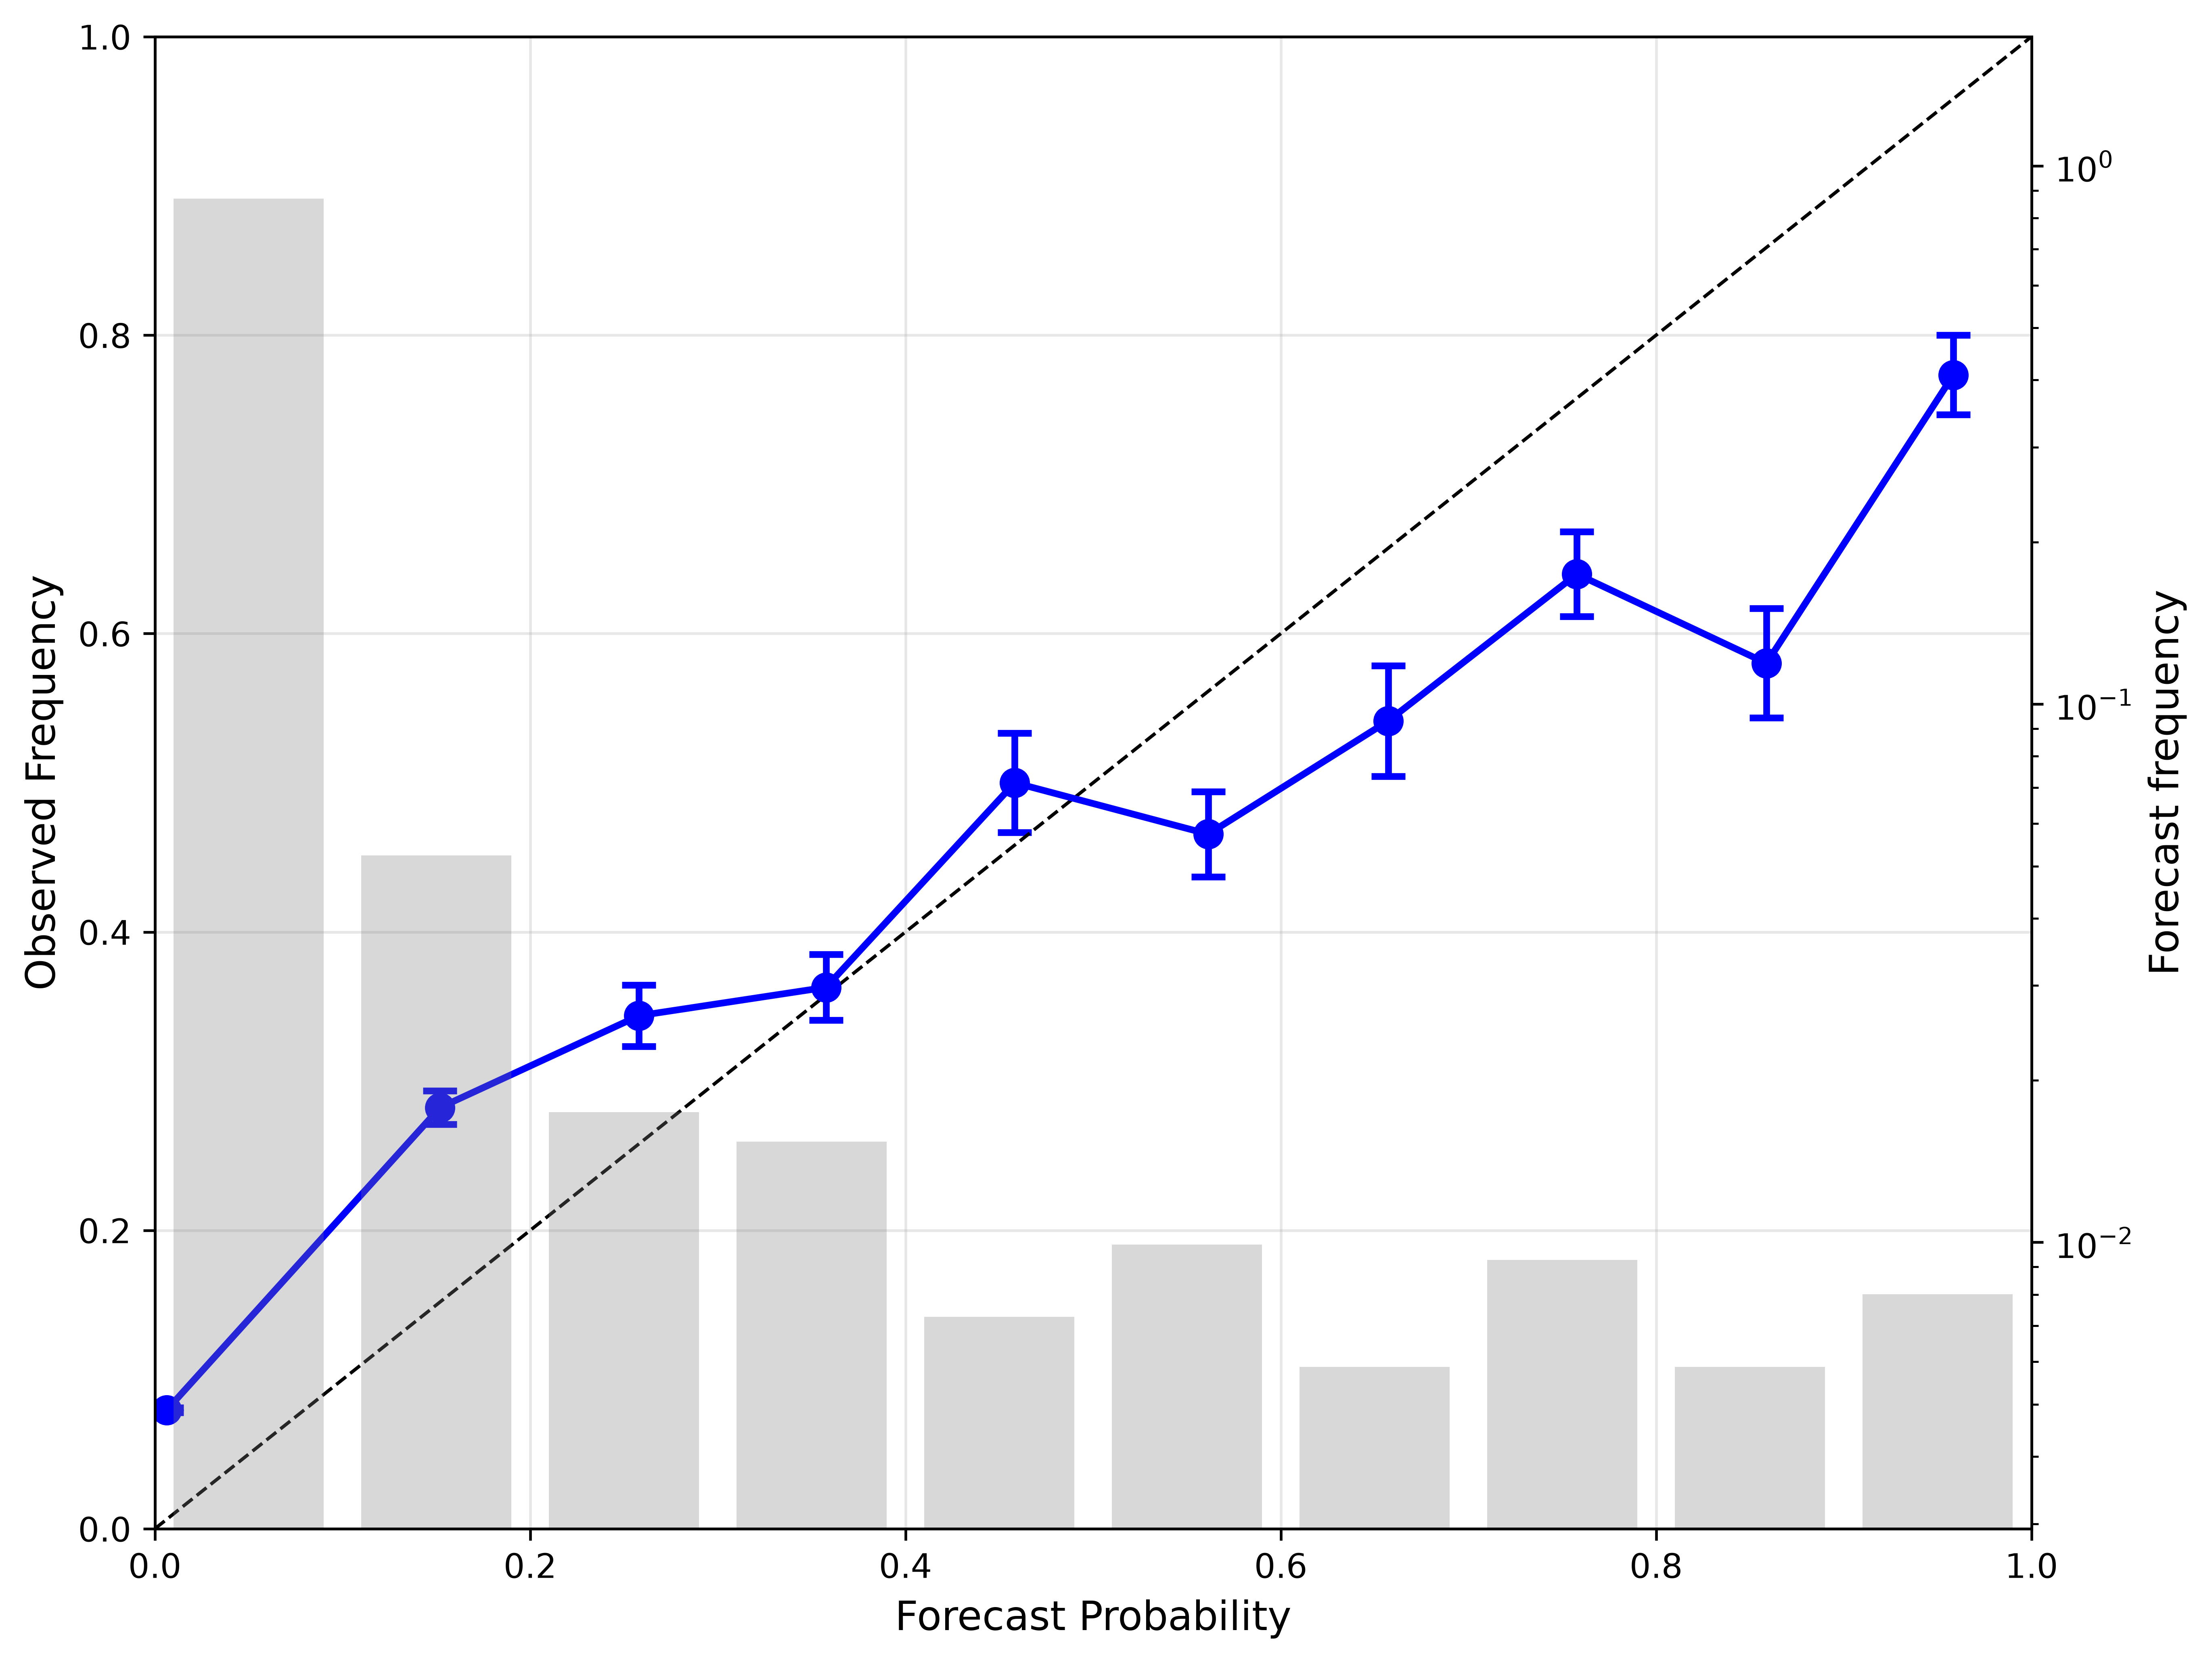

In [16]:

import os
from momp.utils.printing import tuple_to_str
import momp.lib.loader as loader
from pathlib import Path
from IPython.display import Image, display
import momp.app.onset_time_series as ots
ons = ots.obs_onset_analysis
get_cfg = loader.get_cfg
cfg = get_cfg()
base_dir = cfg.base_dir

window = tuple_to_str(cfg.verification_window_list[0])
model = cfg.model_dir_list[0]
dir_fig = cfg.dir_fig
fig_filename = os.path.join(dir_fig,f'reliability_AIFS_{window}.png')
print(f"loading figure{fig_filename}")
display(Image(filename=fig_filename,width=510))


loading figure/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure/reliability_AIFS_16-30.png


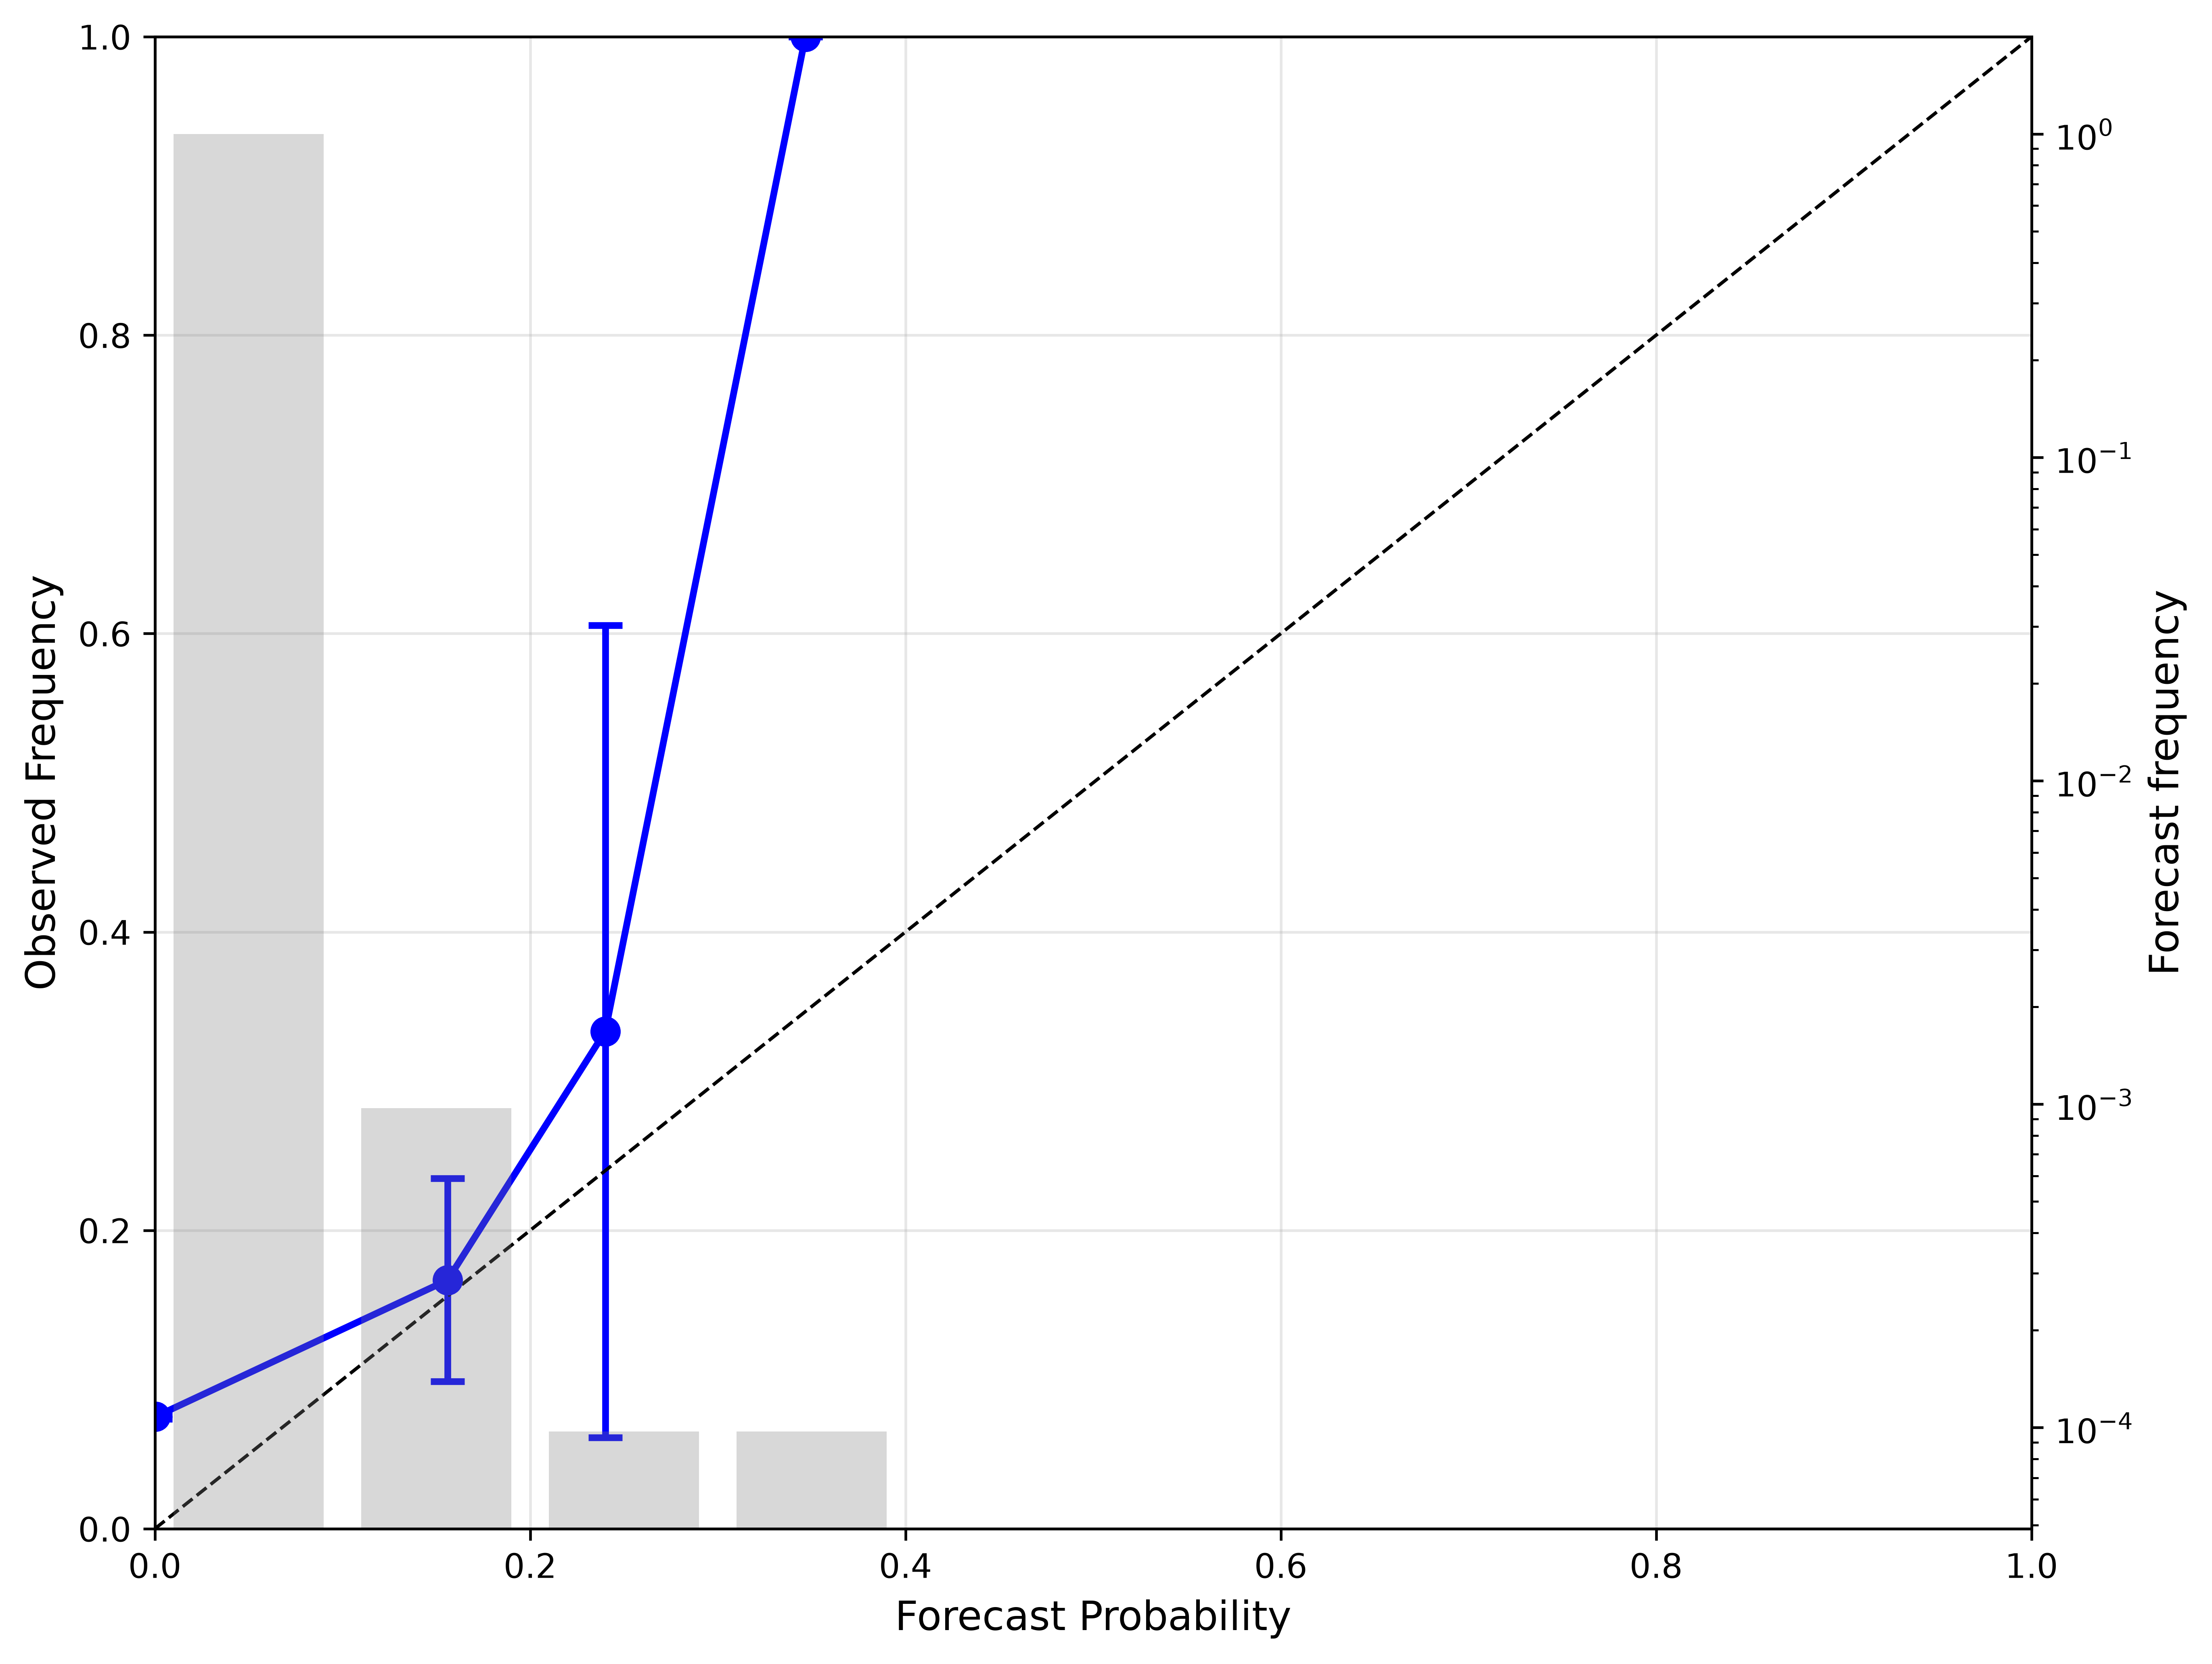

In [58]:

window = tuple_to_str(cfg.verification_window_list[1])
model = cfg.model_dir_list[1]
dir_fig = cfg.dir_fig
fig_filename = os.path.join(dir_fig,f'reliability_AIFS_{window}.png')
print(f"loading figure{fig_filename}")
display(Image(filename=fig_filename,width=510))


In [66]:
!ls ../data/ROMP_OUT/et/figure

climatology_onset.png
climatology_onset_1998-2024.png
climatology_onset_2000-2022.png
climatology_onset_2015-2022.png
daily_rainfall_onset_2020.png
onset_observation_2020.png
onset_skill.png
onset_time_series_lat10_lon40_2015.png
onset_time_series_lat10_lon40_2020.png
onset_time_series_lat7.0_lon39.5_2021.png
onset_time_series_lat7.75_lon38.75_2021.png
onset_time_series_lat8.25_lon39.25_2021.png
onset_time_series_lat8.5_lon38.25_2021.png
onset_time_series_lat8.5_lon39.0_2021.png
onset_time_series_lat8.5_lon39.25_2020.png
onset_time_series_lat8.5_lon39.25_2021.png
onset_time_series_lat9.0_lon39.25_2021.png
panel_bar_BSS_RPSS_AUC_1-15.png
panel_bar_BSS_RPSS_AUC_16-30.png
panel_portrait_BSS_AUC_1-15.png
panel_portrait_BSS_AUC_16-30.png
panel_portrait_mae_far_mr_AIFS_30day.png
panel_portrait_mae_far_mr_AIFS_ENS_30day.png
panel_portrait_mae_far_mr_prob_30day.png
reliability_AIFS_1-15.png
reliability_AIFS_16-30.png
reliability_AIFS_ENS_1-15.png
reliability_AIFS_ENS_16-30.png
reliability_prob

loading figure/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure/skill_scores_heatmap_AIFS_1-15.png


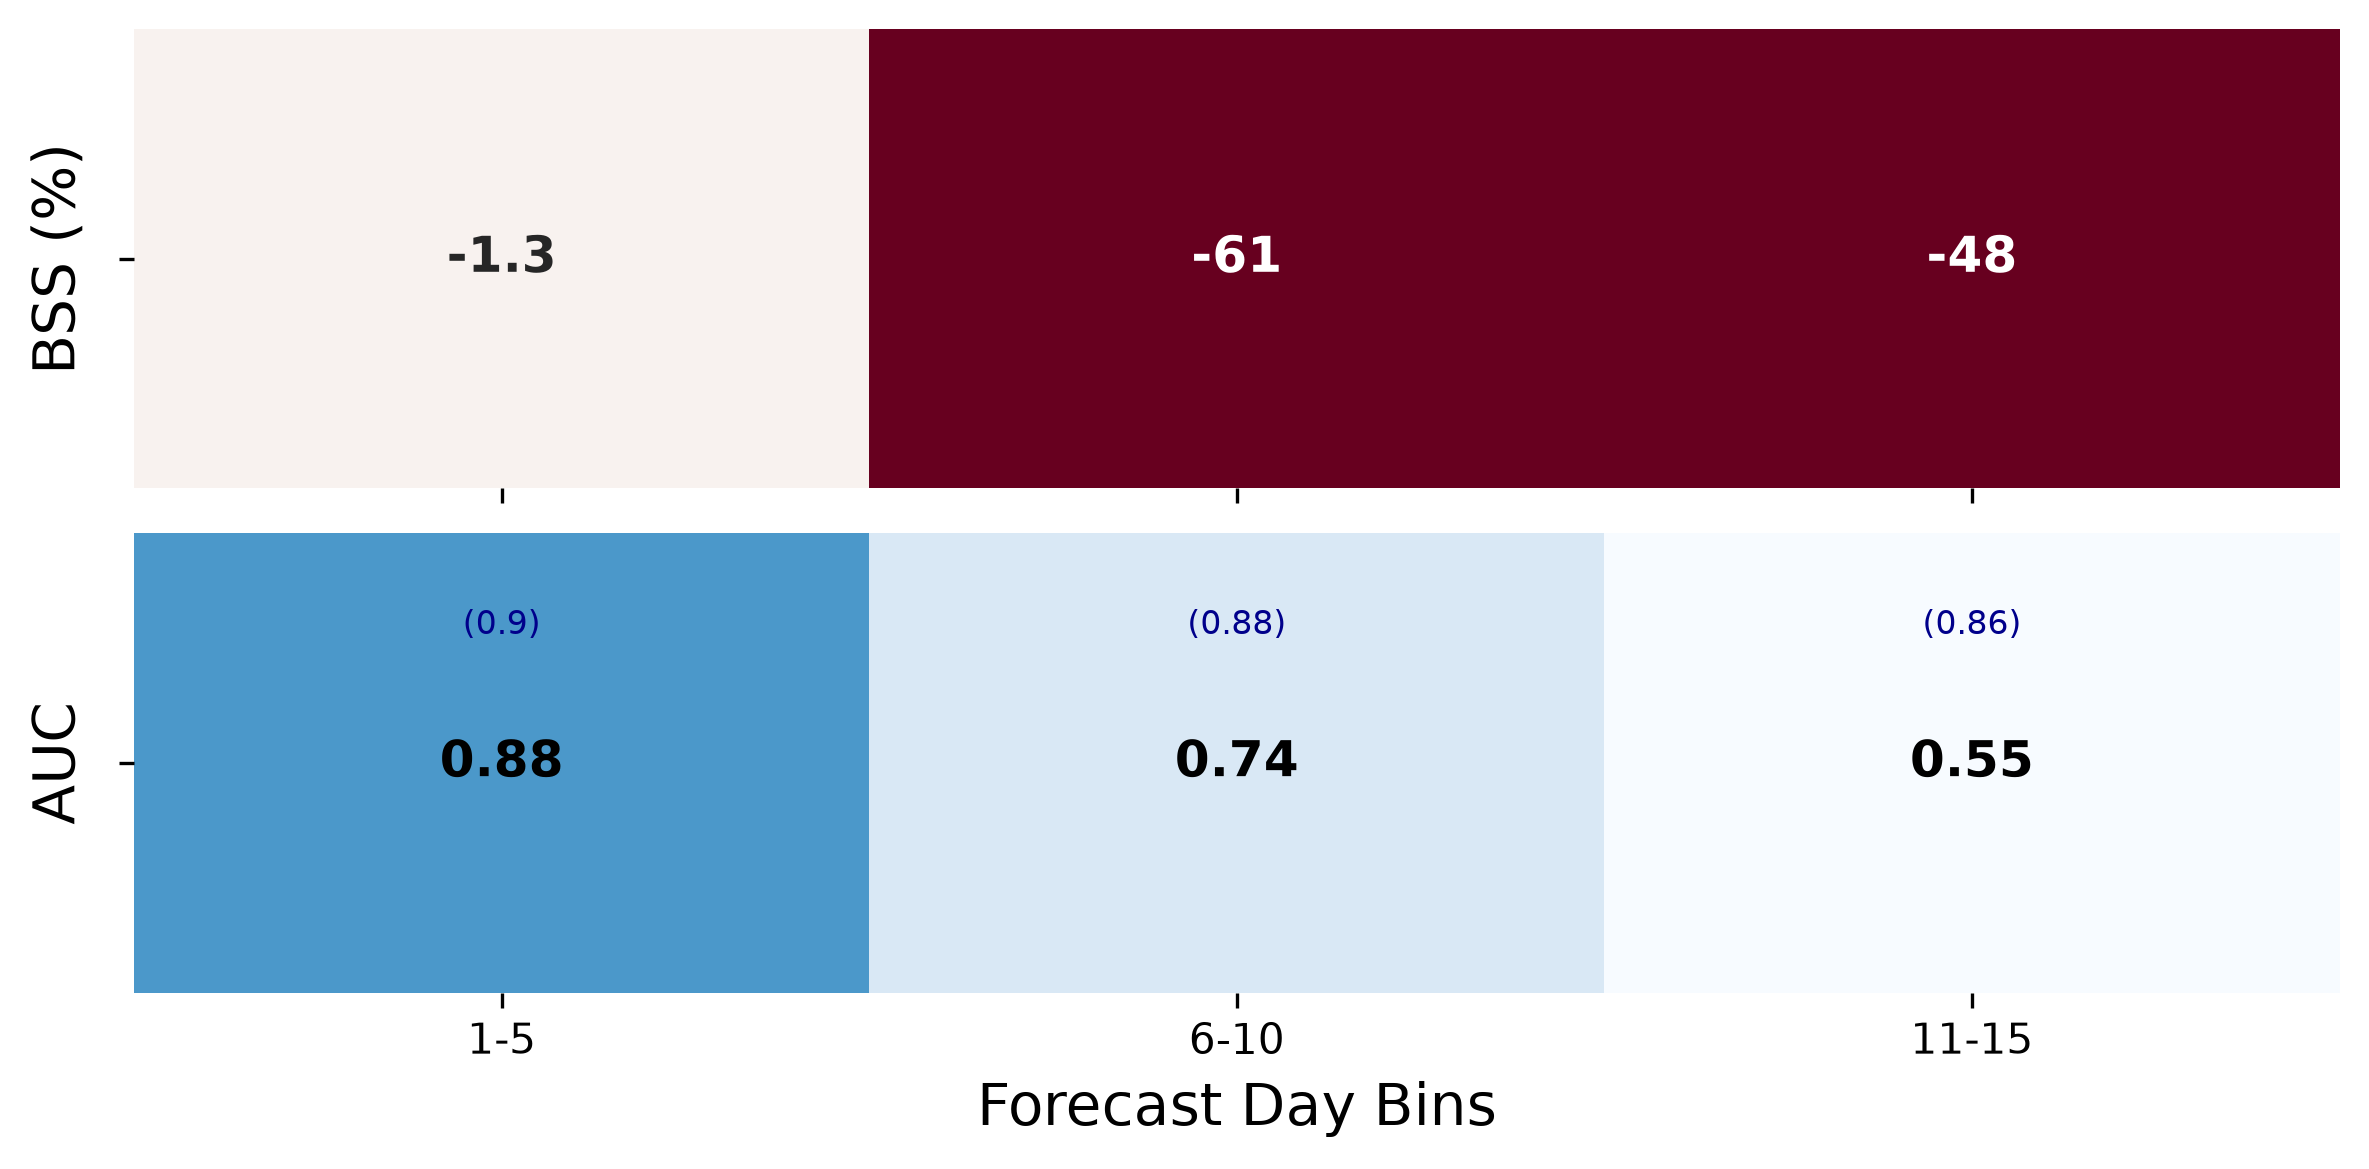

In [72]:

window = tuple_to_str(cfg.verification_window_list[0])
model = cfg.model_dir_list[0]
dir_fig = cfg.dir_fig
fig_filename = os.path.join(dir_fig,f'skill_scores_heatmap_AIFS_{window}.png')
print(f"loading figure{fig_filename}")
display(Image(filename=fig_filename,width=510))


loading figure/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure/skill_scores_heatmap_AIFS_16-30.png


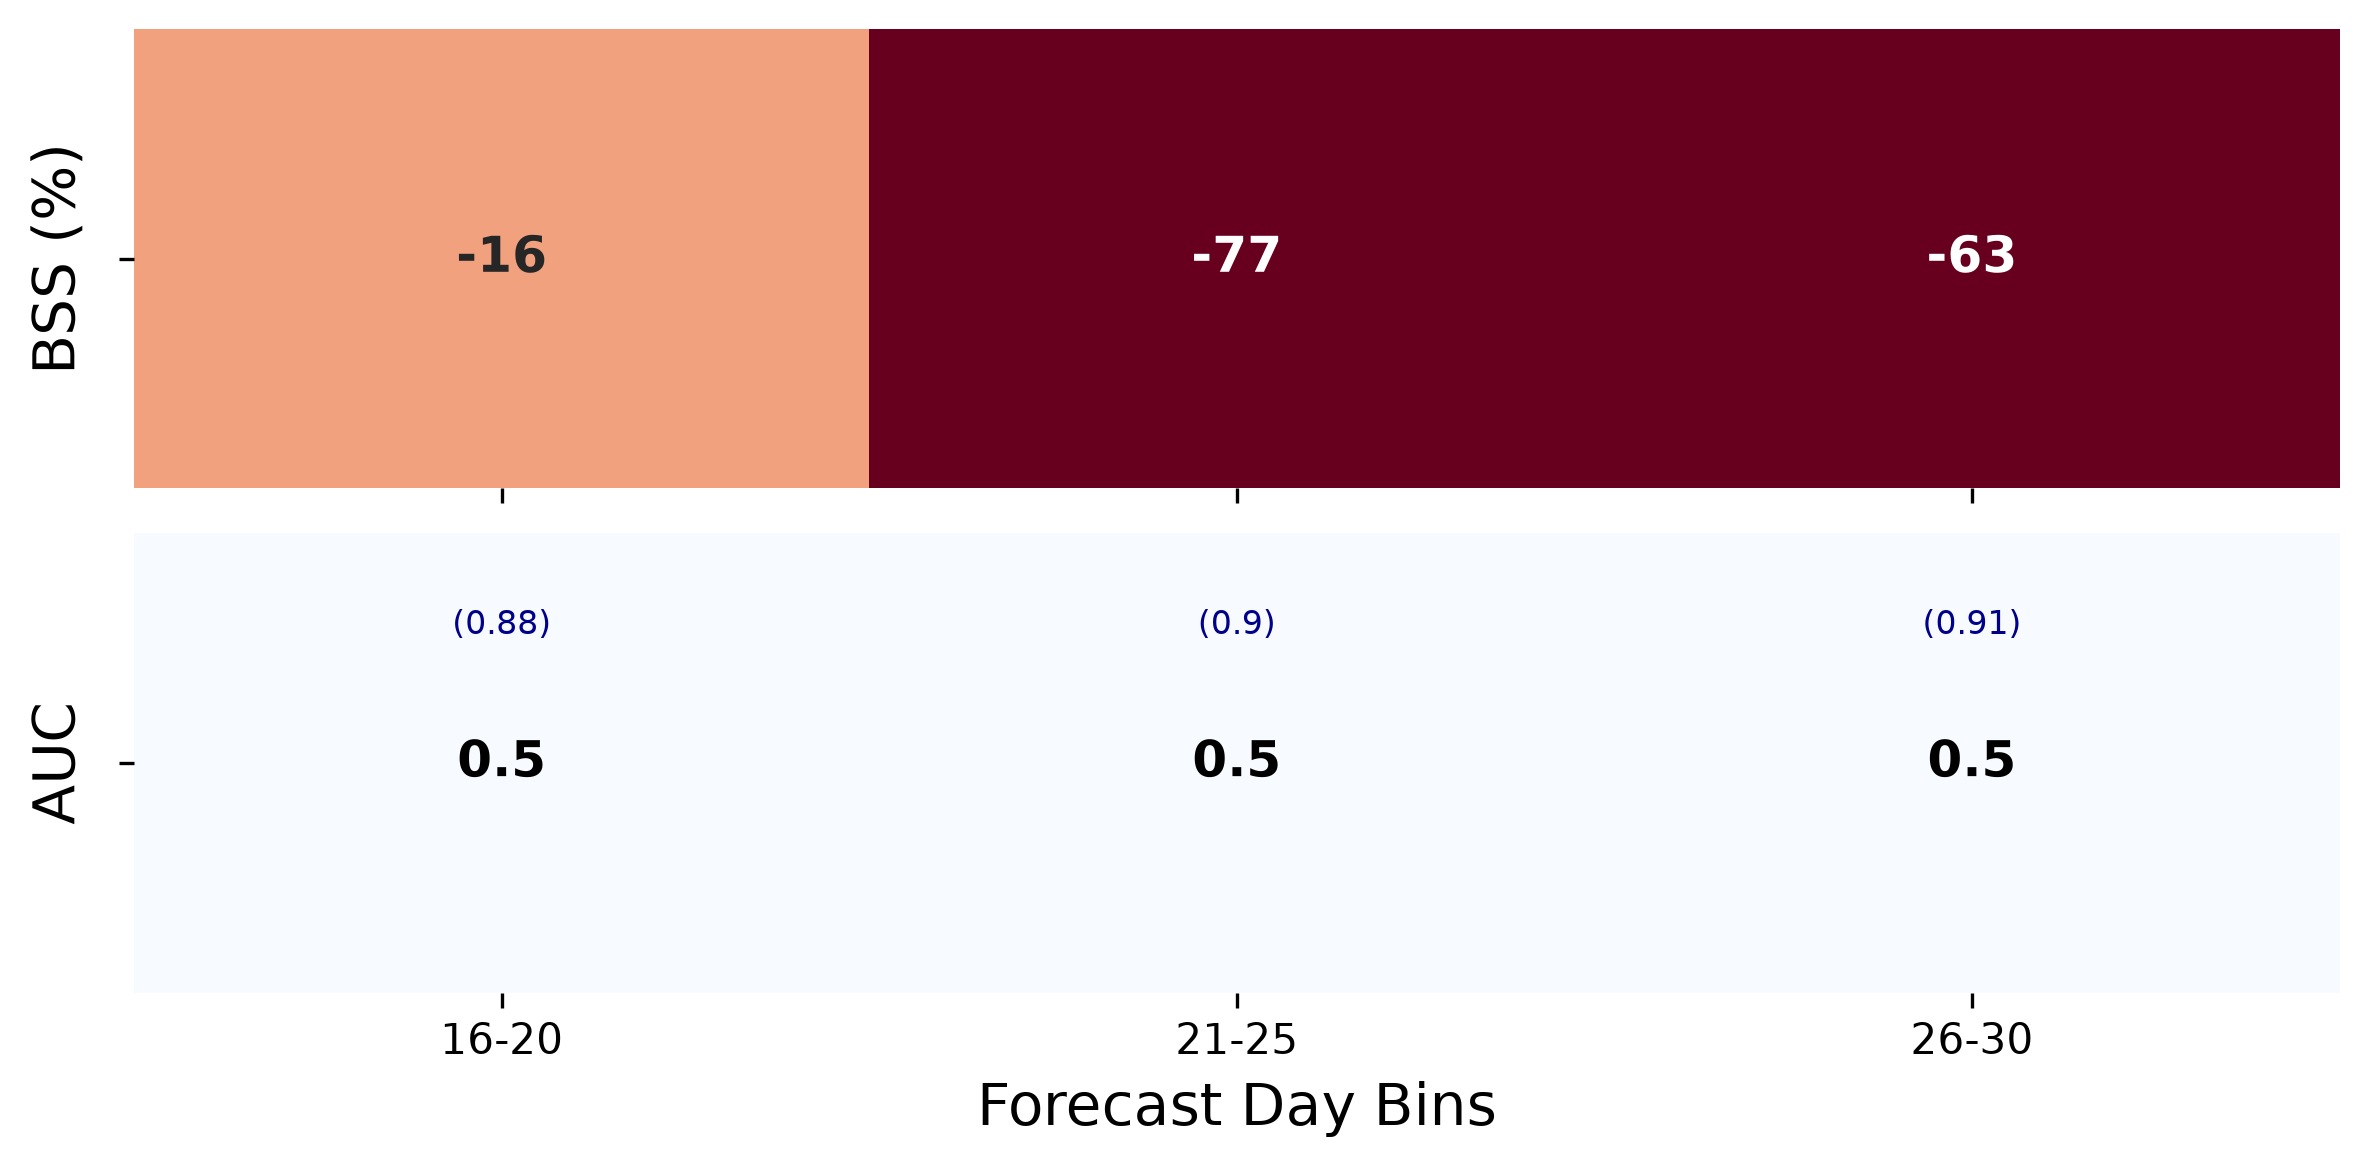

In [73]:
window = tuple_to_str(cfg.verification_window_list[1])
model = cfg.model_dir_list[1]
dir_fig = cfg.dir_fig
fig_filename = os.path.join(dir_fig,f'skill_scores_heatmap_AIFS_{window}.png')
print(f"loading figure{fig_filename}")
display(Image(filename=fig_filename,width=510))

loading figure/Users/mesfind/opt/Research/uchicago/ETAgroMetAIx/HCWF/ETAgroMetAIx/Training/ai-weather/ai_weather/data/ROMP_OUT/et/figure/spatial_metrics_AIFS_1-15.png


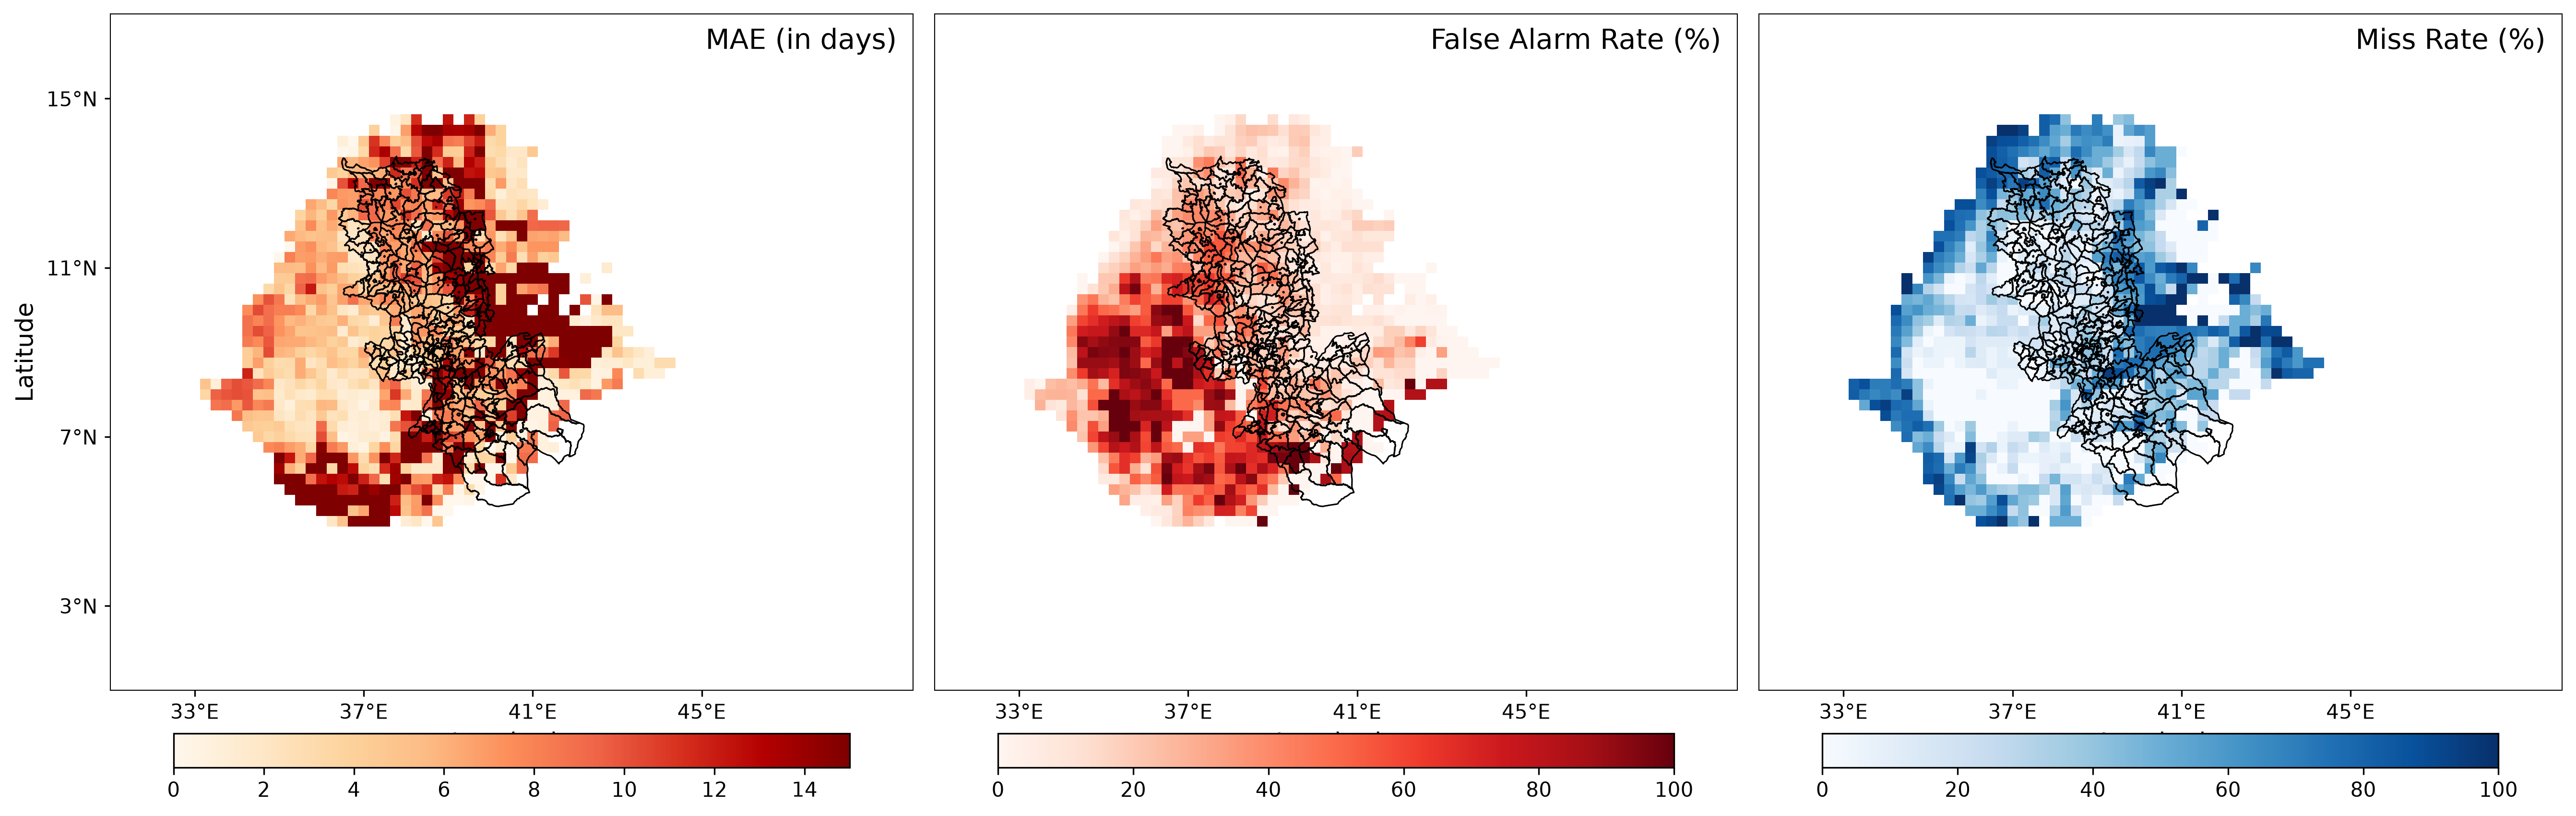

In [74]:
window = tuple_to_str(cfg.verification_window_list[0])
model = cfg.model_list[1]
dir_fig = cfg.dir_fig
fig_filename = os.path.join(dir_fig,f'spatial_metrics_AIFS_{window}.png')
print(f"loading figure{fig_filename}")
display(Image(filename=fig_filename,width=710))

In [17]:
import momp.lib.loader as loader
get_cfg = loader.get_cfg
from pathlib import Path
from IPython.display import Image, display